In [1]:
import os
import torch
import torch

import scipy.sparse as sp
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

from tqdm import tqdm
from pathlib import Path
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

os.environ['R_HOME'] = '/root/miniconda3/envs/njy1/lib/R'
os.environ['R_USER'] = "/root/miniconda3/envs/njy1/lib/python3.9/site-packages/rpy2"

In [2]:
def fix_seed(seed):
    import random
    import torch
    from torch.backends import cudnn

    #seed = 666
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False
    
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [3]:
from GraphST import GraphST

In [4]:
fix_seed(42)

In [5]:
def read_adata(adata_name_list, data_root):
    print("Reading data.")
    for adata_name in tqdm(adata_name_list):
        adata_tmp = sc.read_h5ad(os.path.join(data_root, adata_name + '.MOSTA.h5ad'))
        adata_tmp.var_names_make_unique()
        print("adata {} shape: {}".format(adata_name, adata_tmp.X.shape))

        adata_tmp.obs['timepoint'] = adata_name

        ##### Load label, if have
        # df_label = pd.read_csv(data_root / proj_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
        # df_label.columns = ['annotation']
        # adata_tmp.obs['annotation'] = df_label['annotation']

        if adata_name == adata_name_list[0]:
            adata = adata_tmp
            adata.obs['timepoint'] = adata_name
        else:
            var_names = adata.var_names.intersection(adata_tmp.var_names)
            adata = adata[:, var_names]
            adata_tmp = adata_tmp[:, var_names]
            adata_tmp.obs['timepoint'] = adata_name
            adata = adata.concatenate(adata_tmp)
    print("Finished reading data.")
    return adata


def spatiotemporal_graph_(
               adata_name_list,
               data_root,
               scale_factor=1.5,  # scale factor for spatial coordinates
               rad_cutoff=None,  # cutoff radius of spots for building graph
               k_cutoff=12,
               mode='KNN',
               norm=True, 
               dmax=50
               ):
    if data_root is None:
        raise ValueError("Please provide 'data_root' for reading data!")
    adata = read_adata(adata_name_list, data_root)
    # adata_st = ad.concat(adata_st_list, label="slice_name", keys=section_ids)
    # adata_st.obs['Ground Truth'] = adata_st.obs['Ground Truth'].astype('category')
    # adata_st.obs["slice_name"] = adata_st.obs["slice_name"].astype('category')
    # Build a graph for spots across multiple slices

    adata.obs['timepoint'] = pd.Categorical(adata.obs['timepoint'], categories=adata_name_list, ordered=True)
    adata.obs['timepoint_numeric'] = adata.obs['timepoint'].cat.codes
    loc_tp = np.array(adata.obs['timepoint_numeric']).astype('int')

    loc_xy = adata.obsm['spatial']
    loc_xy_scaled = np.zeros(loc_xy.shape, dtype=np.float64)
    for i in range(len(adata_name_list)):
        scaler = StandardScaler()
        loc_xy_tmp = loc_xy[loc_tp == i, :]
        loc_xy_tmp = scaler.fit_transform(loc_xy_tmp)
        loc_xy_scaled[loc_tp == i, :] = loc_xy_tmp

    loc_tp = loc_tp[:, np.newaxis]
    loc = np.concatenate((loc_xy_scaled, loc_tp), axis=1)
    loc = pd.DataFrame(loc)
    loc.index = adata.obs.index
    loc.columns = ['x', 'y', 'z']

    if rad_cutoff is None:
        # The first adata in adata_list is used as a reference for computing cutoff radius of spots
        loc_ref = loc[loc['z']==0]
        pair_dist_ref = pairwise_distances(loc_ref)
        min_dist_ref = np.sort(np.unique(pair_dist_ref), axis=None)[1]
        rad_cutoff = min_dist_ref * scale_factor
        loc_tp_scaled = np.zeros(loc.shape[0])
        for i in range(len(adata_name_list)):
            loc_tp_scaled[loc['z']==i] = rad_cutoff * i
    else:
        loc_tp_scaled = loc['z'] * rad_cutoff

    loc_scaled = np.concatenate([loc_xy_scaled, loc_tp_scaled.values.reshape(-1, 1)], axis=1)
    loc_scaled = pd.DataFrame(loc_scaled, index=loc.index, columns=['x', 'y', 'z'])
    adata.obsm['loc_scaled'] = loc_scaled

    if mode == 'KNN':
        adj_m1 = generate_adj_mat(adata, include_self=False, n=k_cutoff-1, spatial="loc_scaled")
        # adj_m1 = graph_computing(adata.obsm['spatial'], n=n)
    else:
        adj_m1 = generate_adj_mat_1(adata, dmax, spatial="loc_scaled")
    adj_m1 = sp.coo_matrix(adj_m1)

    # Store original adjacency matrix (without diagonal entries) for later
    adj_m1 = adj_m1 - sp.dia_matrix((adj_m1.diagonal()[np.newaxis, :], [0]), shape=adj_m1.shape)
    adj_m1.eliminate_zeros()

    # Some preprocessing
    if norm:
        adj_norm_m1 = preprocess_graph(adj_m1)
    else:
        adj_norm_m1 = sparse_mx_to_torch_sparse_tensor(adj_m1)
    adj_m1 = adj_m1 + sp.eye(adj_m1.shape[0])
    # adj_label_m1 = torch.FloatTensor(adj_label_m1.toarray())


    adj_m1 = adj_m1.tocoo()
    shape = adj_m1.shape
    values = adj_m1.data
    indices = np.stack([adj_m1.row, adj_m1.col])
    adj_label_m1 = torch.sparse_coo_tensor(indices, values, shape)

    norm_m1 = adj_m1.shape[0] * adj_m1.shape[0] / float((adj_m1.shape[0] * adj_m1.shape[0] - adj_m1.sum()) * 2)

    # # generate random mask
    # adj_mask = mask_generator(adj_label_m1.to_sparse(), N)

    graph_dict = {
        "adj_norm": adj_norm_m1,
        "adj_label": adj_label_m1.coalesce(),
        "norm_value": norm_m1,
    }
    
    return adata, graph_dict

##### generate n
def generate_adj_mat(adata, include_self=False, n=6, spatial="spatial"):
    from sklearn import metrics
    assert spatial in adata.obsm, 'AnnData object should provided spatial information'

    dist = metrics.pairwise_distances(adata.obsm[spatial])
    adj_mat = np.zeros((len(adata), len(adata)))
    for i in range(len(adata)):
        n_neighbors = np.argsort(dist[i, :])[:n+1]
        adj_mat[i, n_neighbors] = 1

    if not include_self:
        x, y = np.diag_indices_from(adj_mat)
        adj_mat[x, y] = 0

    adata.obsm['graph_neigh'] = adj_mat

    adj_mat = adj_mat + adj_mat.T
    adj_mat = adj_mat > 0
    adj_mat = adj_mat.astype(np.int64)

    return adj_mat

def generate_adj_mat_1(adata, max_dist, spatial="spatial"):
    from sklearn import metrics
    assert spatial in adata.obsm, 'AnnData object should provided spatial information'

    dist = metrics.pairwise_distances(adata.obsm[spatial], metric='euclidean')
    adj_mat = dist < max_dist
    adj_mat = adj_mat.astype(np.int64)
    return adj_mat

##### normalze graph
def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

def preprocess_graph(adj):
    adj_ = adj + sp.eye(adj.shape[0])
    rowsum = np.array(adj_.sum(1))
    degree_mat_inv_sqrt = sp.diags(np.power(rowsum, -0.5).flatten())
    adj_normalized = adj_.dot(degree_mat_inv_sqrt).transpose().dot(degree_mat_inv_sqrt).tocoo()
    return sparse_mx_to_torch_sparse_tensor(adj_normalized)


In [6]:
data_root = Path('../../Data/Mouse_Embryo/')

proj_list = [
    'E9.5_E1S1', 'E10.5_E2S1', 'E11.5_E1S1'
]

adata, graph_dict = spatiotemporal_graph_(proj_list, k_cutoff=12, scale_factor=1, mode="KNN", rad_cutoff=0.1, data_root=data_root)

Reading data.


 33%|███▎      | 1/3 [00:00<00:01,  1.52it/s]

adata E9.5_E1S1 shape: (5913, 25568)
adata E10.5_E2S1 shape: (8494, 22385)


/tmp/ipykernel_3873/1738888262.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_tmp.obs['timepoint'] = adata_name
/tmp/ipykernel_3873/1738888262.py:23: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata.concatenate(adata_tmp)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/merge.py:1291: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  concat_annot[label] = label_col
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/merge.py:1291: PerformanceWarning: DataFrame is hig

adata E11.5_E1S1 shape: (30124, 26854)


/tmp/ipykernel_3873/1738888262.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_tmp.obs['timepoint'] = adata_name
/tmp/ipykernel_3873/1738888262.py:23: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata.concatenate(adata_tmp)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/merge.py:1291: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  concat_annot[label] = label_col
100%|██████████| 3/3 [00:12<00:00,  4.11s/it]
/tmp/ipykernel_3873/1738888262.py:47: PerformanceWarning: DataFrame is hig

Finished reading data.


/tmp/ipykernel_3873/1738888262.py:158: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:618.)
  return torch.sparse.FloatTensor(indices, values, shape)


In [7]:
adj_norm = graph_dict['adj_norm'].coalesce()

indices = adj_norm.indices()
values = adj_norm.values()

# 打印前5条边及其权重
for i in range(20):
    print(f"edge {i}: {indices[0, i].item()} -> {indices[1, i].item()}, weight = {values[i].item():.4f}")

edge 0: 0 -> 0, weight = 0.0833
edge 1: 0 -> 1, weight = 0.0833
edge 2: 0 -> 2, weight = 0.0801
edge 3: 0 -> 27, weight = 0.0801
edge 4: 0 -> 28, weight = 0.0801
edge 5: 0 -> 29, weight = 0.0833
edge 6: 0 -> 65, weight = 0.0801
edge 7: 0 -> 66, weight = 0.0833
edge 8: 0 -> 67, weight = 0.0772
edge 9: 0 -> 107, weight = 0.0745
edge 10: 0 -> 9815, weight = 0.0745
edge 11: 0 -> 10949, weight = 0.0772
edge 12: 1 -> 0, weight = 0.0833
edge 13: 1 -> 1, weight = 0.0833
edge 14: 1 -> 2, weight = 0.0801
edge 15: 1 -> 3, weight = 0.0833
edge 16: 1 -> 28, weight = 0.0801
edge 17: 1 -> 29, weight = 0.0833
edge 18: 1 -> 30, weight = 0.0833
edge 19: 1 -> 66, weight = 0.0833


In [9]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = GraphST.GraphST(adata, epochs=1000, device=device)

# train model
adata = model.train()

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


Begin to train ST data...


100%|██████████| 1000/1000 [09:30<00:00,  1.75it/s]


Optimization finished for ST data!


In [10]:
n_clusters = 20
radius = 50

tool = 'mclust' # mclust, leiden, and louvain

# clustering
from GraphST.utils import clustering

if tool == 'mclust':
   clustering(adata, n_clusters, radius=radius, method=tool, refinement=False) # For DLPFC dataset, we use optional refinement step.
elif tool in ['leiden', 'louvain']:
   clustering(adata, n_clusters, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01, refinement=False)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [11]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [12]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['timepoint'] == name]
    ARI = ari_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")

total ARI:0.32181163874684404
E9.5_E1S1 ARI:0.18635801600783794
E10.5_E2S1 ARI:0.16318413088699343
E11.5_E1S1 ARI:0.37031077341602403


In [13]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['timepoint'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} NMI:{NMI}")

total NMI:0.5661034683636521
E9.5_E1S1 NMI:0.4379908966609684
E10.5_E2S1 NMI:0.4829101416816821
E11.5_E1S1 NMI:0.6111132699398591


In [14]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{HOM}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['timepoint'] == name]
    HOM = hom_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} HOM:{HOM}")

total NMI:0.5648014436332011
E9.5_E1S1 HOM:0.3499915542600976
E10.5_E2S1 HOM:0.39334409993032643
E11.5_E1S1 HOM:0.6151945374032879


/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


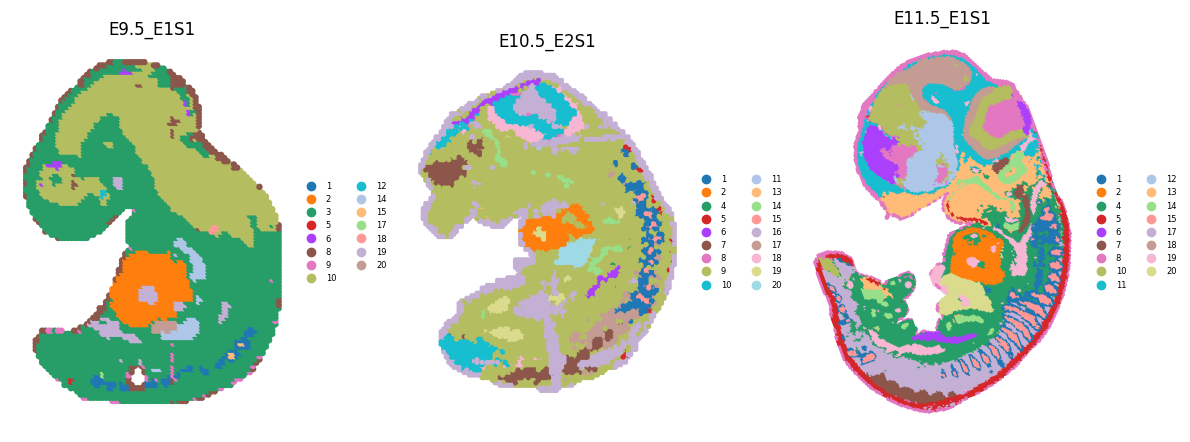

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['timepoint'] == proj_list[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


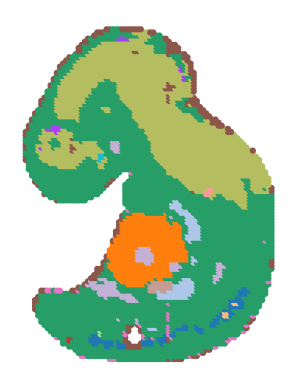

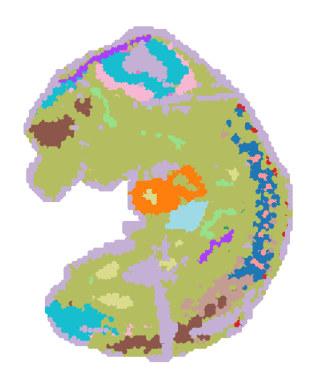

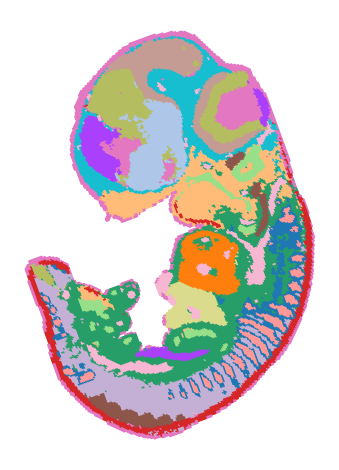

In [20]:
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['timepoint'] == proj_list[slice_id]]
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc=None, legend_fontsize=6, show=False, frameon=False,
                  spot_size=spot_size)
    #plt.title(f'{slice_name}')
    plt.savefig(f'GraphST_{slice_name}.jpg', bbox_inches='tight', dpi=300)
plt.tight_layout()

In [31]:
adata

AnnData object with n_obs × n_vars = 44531 × 22143
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - 2310011J03Rik', 'Regulon - 5730507C01Rik', 'Regulon - Alx1', 'Regulon - Alx3', 'Regulon - Alx4', 'Regulon - Ar', 'Regulon - Arid3a', 'Regulon - Arid3c', 'Regulon - Arnt2', 'Regulon - Arx', 'Regulon - Ascl1', 'Regulon - Atf1', 'Regulon - Atf4', 'Regulon - Atf5', 'Regulon - Atf6', 'Regulon - Atf7', 'Regulon - Bach1', 'Regulon - Bach2', 'Regulon - Barhl1', 'Regulon - Barx1', 'Regulon - Batf', 'Regulon - Bcl11a', 'Regulon - Bcl3', 'Regulon - Bcl6', 'Regulon - Bcl6b', 'Regulon - Bclaf1', 'Regulon - Bdp1', 'Regulon - Bhlha15', 'Regulon - Bhlhe22', 'Regulon - Bhlhe23', 'Regulon - Bhlhe41', 'Regulon - Bmyc', 'Regulon - Boll', 'Regulon - Bptf', 'Regulon - Brca1', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Bsx', 'Regulon - Cdx1', 'Regulon - Cdx2', 'Regulon - Cebpa', 'Regulon - Cebpz', 'Regulon - Chd1', 'Regulon - Clock', 'R